In [43]:
import numpy as np
import pandas as pd
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from IPython.display import Image
from io import StringIO
import pydotplus

In [44]:
# arquivo com os dados
input_file = "arquivos/PastHires.csv"
# lendo o csv
df = pd.read_csv(input_file, header=0)

In [45]:
df.head()

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,Y,4,BS,N,N,Y
1,0,N,0,BS,Y,Y,Y
2,7,N,6,BS,N,N,N
3,2,Y,1,MS,Y,N,Y
4,20,N,2,PhD,Y,N,N


O scikit-learn precisa que tudo seja numérico para que as árvores de decisão funcionem. Então, mapearemos Y, N para 1, 0 e os níveis de escolaridade para alguma escala de 0 a 2. No mundo real, você precisaria pensar em como lidar com dados inesperados ou ausentes! Ao usar map(), sabemos que obteremos NaN para valores inesperados.

In [46]:
# convertendo sim e nao para binarios
d = {'Y': 1, 'N': 0}
df['Hired'] = df['Hired'].map(d)
df['Employed?'] = df['Employed?'].map(d)
df['Top-tier school'] = df['Top-tier school'].map(d)
df['Interned'] = df['Interned'].map(d)

# convertendo niveis de educacao para numeros de 0 a 2
d = {'BS': 0, 'MS': 1, 'PhD': 2}
df['Level of Education'] = df['Level of Education'].map(d)

df.head()

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,1,4,0,0,0,1
1,0,0,0,0,1,1,1
2,7,0,6,0,0,0,0
3,2,1,1,1,1,0,1
4,20,0,2,2,1,0,0


In [47]:
# listando os atributos
features = list(df.columns[:6])
features

['Years Experience',
 'Employed?',
 'Previous employers',
 'Level of Education',
 'Top-tier school',
 'Interned']

In [48]:
# separando os dados de treino
y = df['Hired']
X = df[features]
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X, y)

In [49]:
df[features].head()

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned
0,10,1,4,0,0,0
1,0,0,0,0,1,1
2,7,0,6,0,0,0
3,2,1,1,1,1,0
4,20,0,2,2,1,0


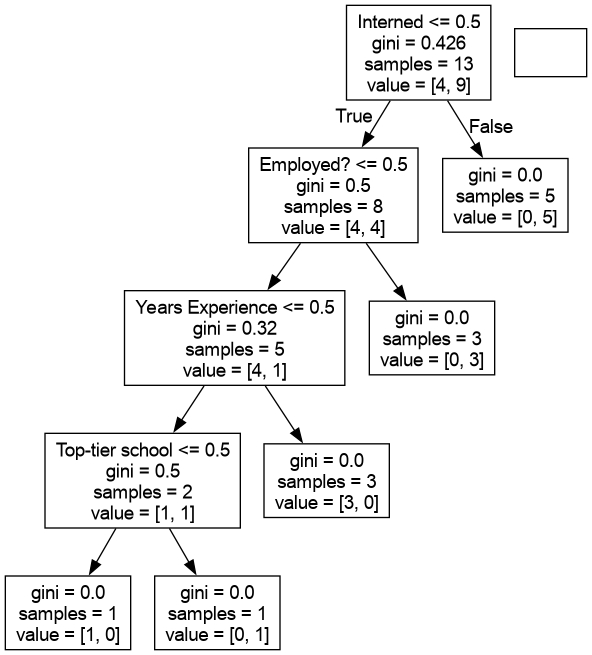

In [50]:
# cria um arquivo virtual
dot_data = StringIO()
# exporta a arvore para o arquivo virtual
tree.export_graphviz(clf, out_file=dot_data,
                        feature_names=features)
# cria o grafo a partir do arquivo virtual
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

In [51]:
# numero de arvores na floresta
clf = RandomForestClassifier(n_estimators=10)
# treinando o modelo
clf = clf.fit(X, y)

In [52]:
print(clf.predict([[10, 1, 4, 0, 0, 0]]))
print(clf.predict([[10, 0, 4, 0, 0, 0]]))

[1]
[0]


/home/liperasz/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/liperasz/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Activity

Modify the test data to create an alternate universe where everyone I hire everyone I normally woudn't have, and vice versa. Compare the resulting decision tree to the one from the original data

In [53]:
# invertendo os valores de contratado
df['Hired'] = df['Hired'].map({1: 0, 0: 1})

In [54]:
# listando os atributos
features = list(df.columns[:6])
features

['Years Experience',
 'Employed?',
 'Previous employers',
 'Level of Education',
 'Top-tier school',
 'Interned']

In [ ]:
# separando os dados de treino
y = df['Hired']
X = df[features]

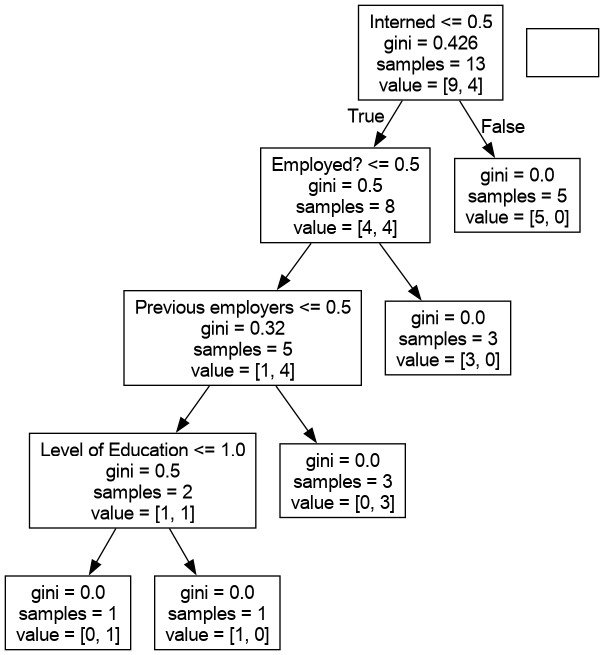

In [59]:
# treinando a árvore de decisão
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X, y)

# cria um arquivo virtual
dot_data = StringIO()
# exporta a arvore para o arquivo virtual
tree.export_graphviz(clf, out_file=dot_data,
                        feature_names=features)
# cria o grafo a partir do arquivo virtual
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

In [56]:
# numero de arvores na floresta
clf = RandomForestClassifier(n_estimators=10)
# treinando o modelo
clf = clf.fit(X, y)

In [57]:
print(clf.predict([[0, 0, 4, 0, 0, 0]]))
print(clf.predict([[10, 0, 4, 0, 0, 0]]))

[1]
[1]


/home/liperasz/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/liperasz/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Os valores que antes significavam bastante coisas, como estagio, agora faz com que seja algo pior